# Sales Prediction Using Python

## Data Collection & Loading

This section focuses on importing the required Python libraries and loading the advertising dataset for sales prediction.


In [2]:
# Cell 1: Data Collection & Data Loading – Importing Libraries, Loading Advertising Dataset and Creating DataFrame

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Advertising dataset
sales_df = pd.read_csv("Advertising (2).csv")

# Display the first five rows
sales_df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Data Understanding & Exploration

This section examines the structure, data types, missing values and statistical characteristics of the advertising dataset.

In [3]:
od

Dataset Shape: (200, 5)

Column Names:
['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']

Data Types:
Unnamed: 0      int64
TV            float64
radio         float64
newspaper     float64
sales         float64
dtype: object

Missing Values:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Descriptive Statistics:


,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## Data Cleaning & Preparation

This section prepares the advertising dataset for analysis by checking and handling missing values and duplicate records.

In [4]:
# Cell 3: Data Cleaning & Preparation – Handling Missing Values and Duplicate Records

# Check and remove duplicate rows
duplicate_count = sales_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

sales_df = sales_df.drop_duplicates().copy()

# Check missing values
missing_values = sales_df.isnull().sum()
print("\nMissing values before cleaning:")
print(missing_values)

# Remove rows containing missing values
sales_df = sales_df.dropna().copy()

print("\nMissing values after cleaning:")
print(sales_df.isnull().sum())

print("\nData cleaning and preparation completed successfully!")
print("Final dataset shape:", sales_df.shape)

Duplicate rows: 0

Missing values before cleaning:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Missing values after cleaning:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Data cleaning and preparation completed successfully!
Final dataset shape: (200, 5)


In [8]:
print(sales_df.columns.tolist())


['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']


## Exploratory Data Analysis (EDA)

This section visualizes the relationships between advertising expenditure and sales to understand how different advertising channels are associated with sales performance.

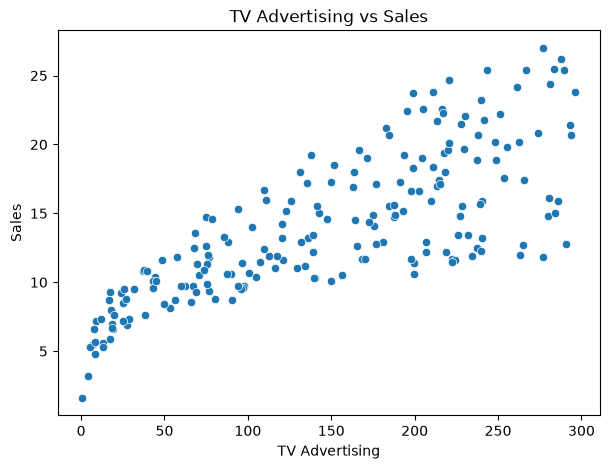

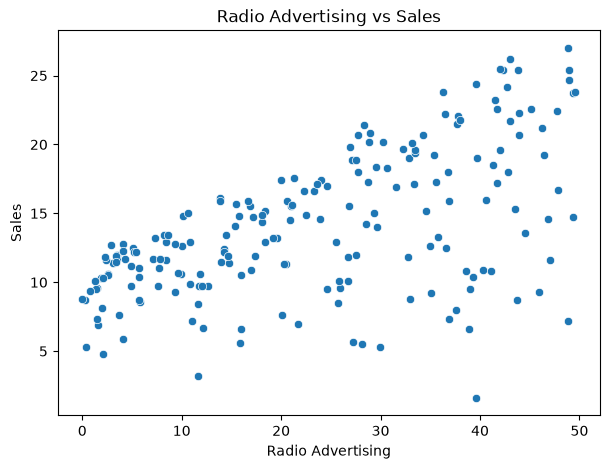

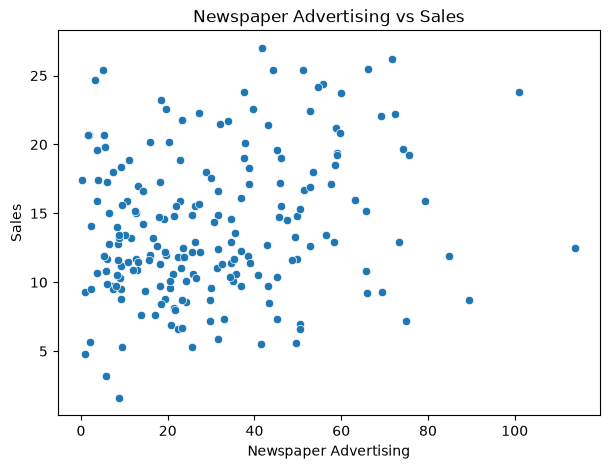

Correlation Matrix:
                 TV     radio  newspaper     sales
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000


In [9]:
# Cell 4: Exploratory Data Analysis – Visualizing Relationships Between Advertising Channels and Sales

# Remove unnecessary index column
sales_df = sales_df.drop(columns=["Unnamed: 0"], errors="ignore")

# TV Advertising vs Sales
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sales_df, x="TV", y="sales")
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.show()

# Radio Advertising vs Sales
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sales_df, x="radio", y="sales")
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.show()

# Newspaper Advertising vs Sales
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sales_df, x="newspaper", y="sales")
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.show()

# Display correlation matrix
print("Correlation Matrix:")
print(sales_df.corr(numeric_only=True))

Feature Preparation & Train-Test Split
This section separates the advertising features from the sales target variable and divides the dataset into training and testing sets.

In [14]:
# Cell 7: Model Training – Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("Random Forest Regressor trained successfully.")


Random Forest Regressor trained successfully.


In [15]:
# Cell 8: Model Evaluation – MAE, RMSE, and R² Score for Both Models

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.3f}\n")
    return mae, rmse, r2

lr_metrics = evaluate("Linear Regression", y_test, y_pred_lr)
rf_metrics = evaluate("Random Forest Regressor", y_test, y_pred_rf)

--- Linear Regression ---
MAE:  1.461
RMSE: 1.782
R²:   0.899

--- Random Forest Regressor ---
MAE:  0.620
RMSE: 0.769
R²:   0.981



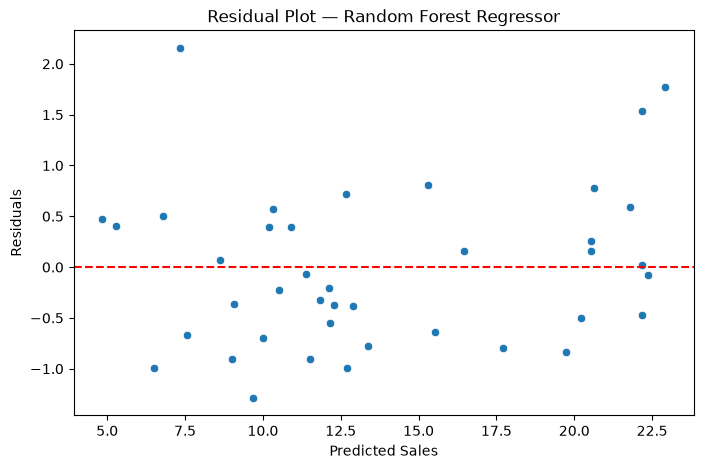

In [16]:
# Cell 9: Residual Analysis – Checking Residual Distribution for the Best Model

residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_rf, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot — Random Forest Regressor")
plt.show()

## Feature Preparation & Train-Test Split

This section separates the advertising features from the sales target variable and divides the dataset into training and testing sets.

In [18]:
# Cell 5: Feature Preparation & Train-Test Split – Separating Features and Target and Splitting the Dataset

from sklearn.model_selection import train_test_split

# Separate features and target
X = sales_df[["TV", "radio", "newspaper"]]
y = sales_df["sales"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget variable: Sales")

Training data shape: (160, 3)
Testing data shape: (40, 3)

Feature columns:
['TV', 'radio', 'newspaper']

Target variable: Sales


## Regression Model Building & Evaluation

This section trains a Linear Regression model to predict sales and evaluates its performance using MAE, MSE, RMSE and R² score.

In [19]:
# Cell 6: Regression Model Building & Evaluation – Training Linear Regression and Measuring Performance

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Performance")
print("-----------------------------------")
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R² Score:", round(r2, 4))

Linear Regression Model Performance
-----------------------------------
Mean Absolute Error (MAE): 1.4608
Mean Squared Error (MSE): 3.1741
Root Mean Squared Error (RMSE): 1.7816
R² Score: 0.8994


## Prediction & Performance Visualization

This section compares actual sales with predicted sales and visualizes the performance of the regression model.

Actual vs Predicted Sales:


,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


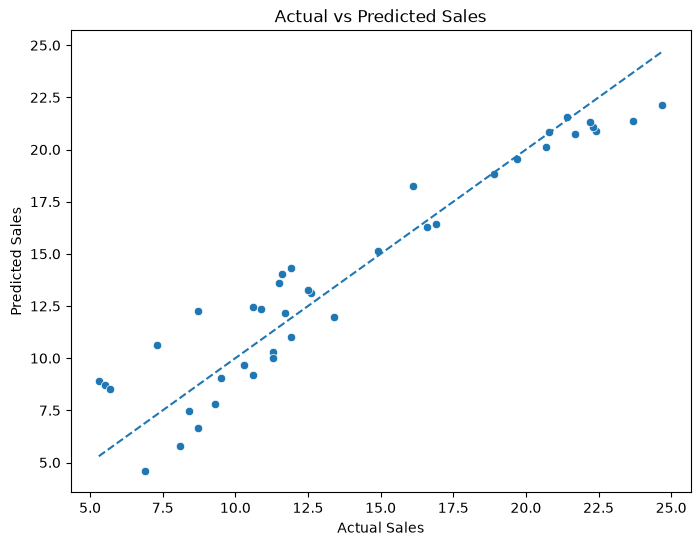


Sales prediction analysis completed successfully!


In [20]:
# Cell 7: Prediction & Performance Visualization – Comparing Actual and Predicted Sales

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

# Display the first ten predictions
print("Actual vs Predicted Sales:")
display(comparison_df.head(10))

# Plot actual vs predicted sales
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

print("\nSales prediction analysis completed successfully!")